# Exploratory Data Analysis of AQI

This notebook performs a structured exploratory analysis of the feature-engineered AQI dataset.

The analysis focuses on:

- Dataset structure and quality
- Temporal behaviour of AQI
- Distribution of AQI and pollutant variables
- Statistical relationships between pollutants and AQI
- Correlation analysis
- Outlier investigation
- Weekday-based observations
- Relationships among engineered features
- Analytical findings and limitations

The objective is to understand the statistical and temporal characteristics of the dataset before model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Feature-Engineered Dataset

The feature-engineered dataset generated in the previous stage is loaded for exploratory analysis.

The datetime column is converted to pandas datetime format and the observations are ordered chronologically.

In [2]:
df = pd.read_csv("../data/processed/AQI_feature_engineered.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime").reset_index(drop=True)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (120, 17)


,datetime,AQI,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,hour,day,month,weekday,AQI_lag_1,AQI_change,AQI_rolling_avg
0,2026-08-30 03:00:00,2,70.64,0.05,1.18,35.02,0.90,6.99,20.53,0.00,3,30,8,6,NaN,0.0,2.000000
1,2026-08-30 04:00:00,1,71.37,0.13,1.16,36.15,0.96,6.50,18.09,0.00,4,30,8,6,2.0,-1.0,2.000000
2,2026-08-30 05:00:00,1,71.14,0.17,0.98,38.45,0.94,6.11,15.69,0.00,5,30,8,6,1.0,0.0,1.500000
3,2026-08-30 06:00:00,1,70.22,0.16,0.77,41.43,0.91,6.07,14.75,0.01,6,30,8,6,1.0,0.0,1.333333
4,2026-08-30 07:00:00,1,70.41,0.11,0.71,43.64,0.87,6.01,15.01,0.00,7,30,8,6,1.0,0.0,1.000000


## 2. Dataset Structure and Data Quality

Before performing statistical analysis, the structure of the dataset is examined.

This step verifies the number of observations, variables, data types, missing values, and duplicate records.

In [3]:
print("Number of observations:", df.shape[0])
print("Number of features:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

Number of observations: 120
Number of features: 17

Data Types:
datetime           datetime64[us]
AQI                         int64
CO                        float64
NO                        float64
NO2                       float64
O3                        float64
SO2                       float64
PM2_5                     float64
PM10                      float64
NH3                       float64
hour                        int64
day                         int64
month                       int64
weekday                     int64
AQI_lag_1                 float64
AQI_change                float64
AQI_rolling_avg           float64
dtype: object


In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
datetime           0
AQI                0
CO                 0
NO                 0
NO2                0
O3                 0
SO2                0
PM2_5              0
PM10               0
NH3                0
hour               0
day                0
month              0
weekday            0
AQI_lag_1          1
AQI_change         0
AQI_rolling_avg    0
dtype: int64

Duplicate Rows: 0


## 3. Descriptive Statistical Analysis

Descriptive statistics are used to examine the central tendency, dispersion, and range of the numerical variables.

Mean, standard deviation, minimum, maximum, and quartile values provide an initial statistical profile of AQI and pollutant concentrations.

In [5]:
numeric_columns = df.select_dtypes(include="number").columns

summary = df[numeric_columns].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
AQI,120.0,1.050000,0.218859,1.00,1.0000,1.000,1.0000,2.00
CO,120.0,72.448083,3.286824,66.07,70.2350,72.070,74.2650,79.47
NO,120.0,0.064250,0.076879,0.00,0.0000,0.005,0.1400,0.25
NO2,120.0,1.181500,0.320644,0.62,0.9175,1.160,1.4500,1.85
O3,120.0,37.789000,5.616373,27.88,34.1175,35.905,41.6225,52.05
SO2,120.0,0.944750,0.129673,0.70,0.8600,0.920,1.0200,1.32
PM2_5,120.0,5.314500,1.259959,3.11,4.5300,5.230,6.0025,8.11
PM10,120.0,13.934750,3.172698,7.68,11.8125,14.160,15.3325,23.58
NH3,120.0,0.003667,0.006342,0.00,0.0000,0.000,0.0100,0.02
hour,120.0,11.500000,6.951211,0.00,5.7500,11.500,17.2500,23.00


## 4. AQI Behaviour Over Time

AQI is a time-dependent environmental variable. A chronological visualization is therefore used to examine temporal variation, fluctuations, and potential short-term patterns.

This analysis is descriptive and does not assume the presence of long-term seasonality because the available observation period is limited.

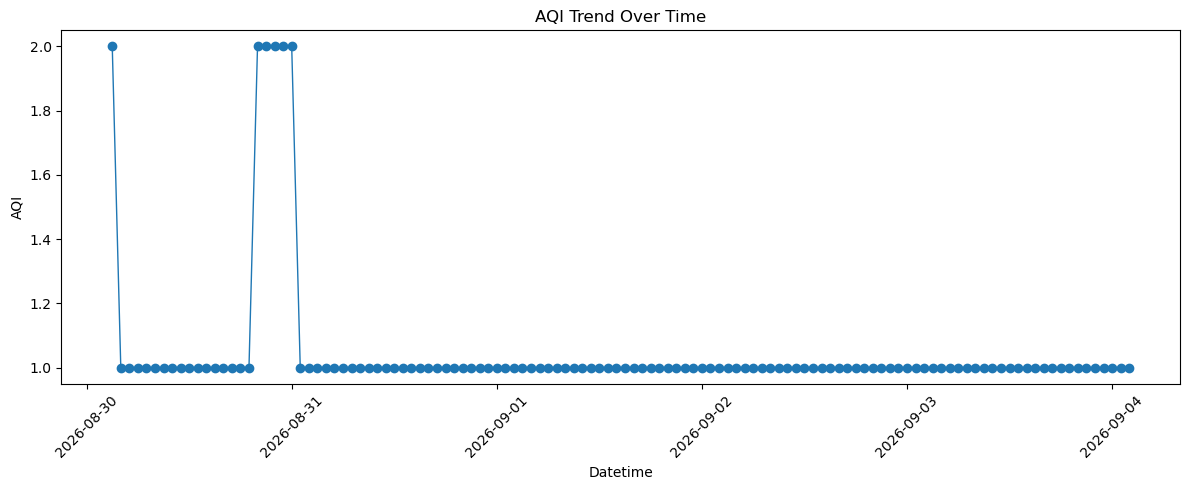

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["AQI"],
    marker="o",
    linewidth=1
)

plt.title("AQI Trend Over Time")
plt.xlabel("Datetime")
plt.ylabel("AQI")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Short-Term AQI Change

The AQI change feature represents the difference between consecutive observations.

Examining this variable helps identify short-term increases and decreases in air-quality conditions.

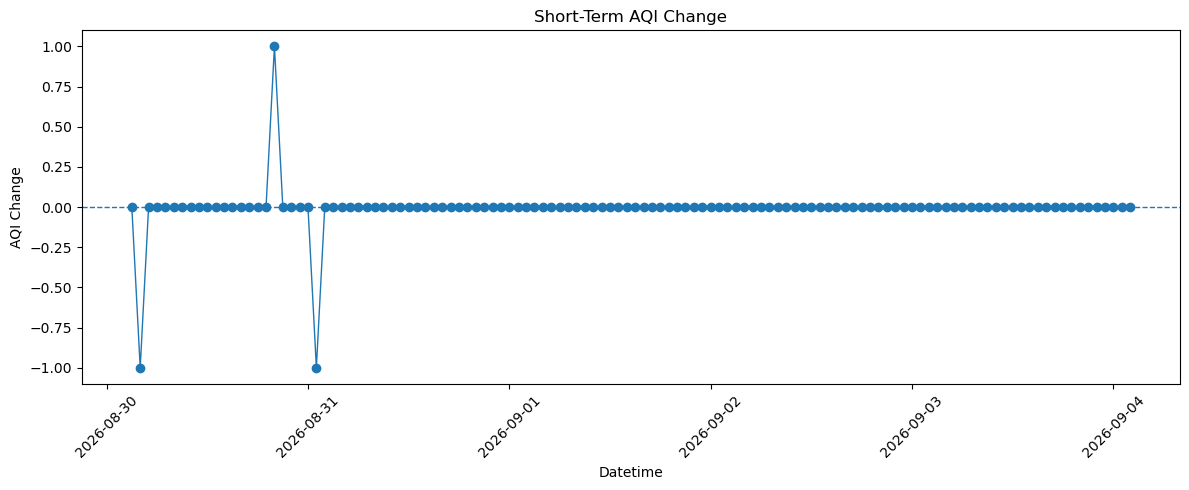

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["AQI_change"],
    marker="o",
    linewidth=1
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Short-Term AQI Change")
plt.xlabel("Datetime")
plt.ylabel("AQI Change")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. AQI Distribution

The distribution of AQI values is examined to understand the frequency of different AQI levels within the collected observations.

Because the OpenWeather AQI field uses a discrete scale, the distribution is interpreted as a frequency distribution rather than assuming continuous normality.

In [8]:
aqi_counts = df["AQI"].value_counts().sort_index()

print(aqi_counts)

AQI
1    114
2      6
Name: count, dtype: int64


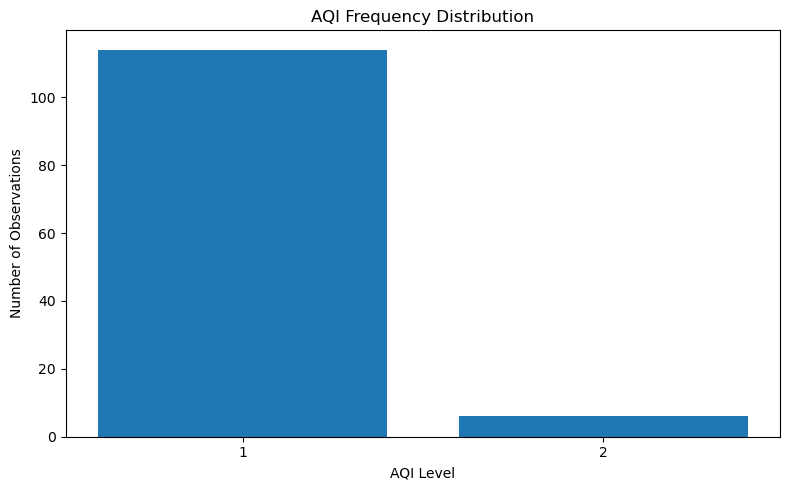

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    aqi_counts.index.astype(str),
    aqi_counts.values
)

plt.title("AQI Frequency Distribution")
plt.xlabel("AQI Level")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

## 7. Pollutant Distribution Analysis

The distributions of major pollutant variables are examined individually.

This analysis helps identify skewness, concentration ranges, variability, and potentially extreme observations that may require attention during model development.

In [10]:
pollutant_columns = [
    "CO",
    "NO",
    "NO2",
    "O3",
    "SO2",
    "PM2_5",
    "PM10",
    "NH3"
]

df[pollutant_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CO,120.0,72.448083,3.286824,66.07,70.2350,72.070,74.2650,79.47
NO,120.0,0.064250,0.076879,0.00,0.0000,0.005,0.1400,0.25
NO2,120.0,1.181500,0.320644,0.62,0.9175,1.160,1.4500,1.85
O3,120.0,37.789000,5.616373,27.88,34.1175,35.905,41.6225,52.05
SO2,120.0,0.944750,0.129673,0.70,0.8600,0.920,1.0200,1.32
PM2_5,120.0,5.314500,1.259959,3.11,4.5300,5.230,6.0025,8.11
PM10,120.0,13.934750,3.172698,7.68,11.8125,14.160,15.3325,23.58
NH3,120.0,0.003667,0.006342,0.00,0.0000,0.000,0.0100,0.02


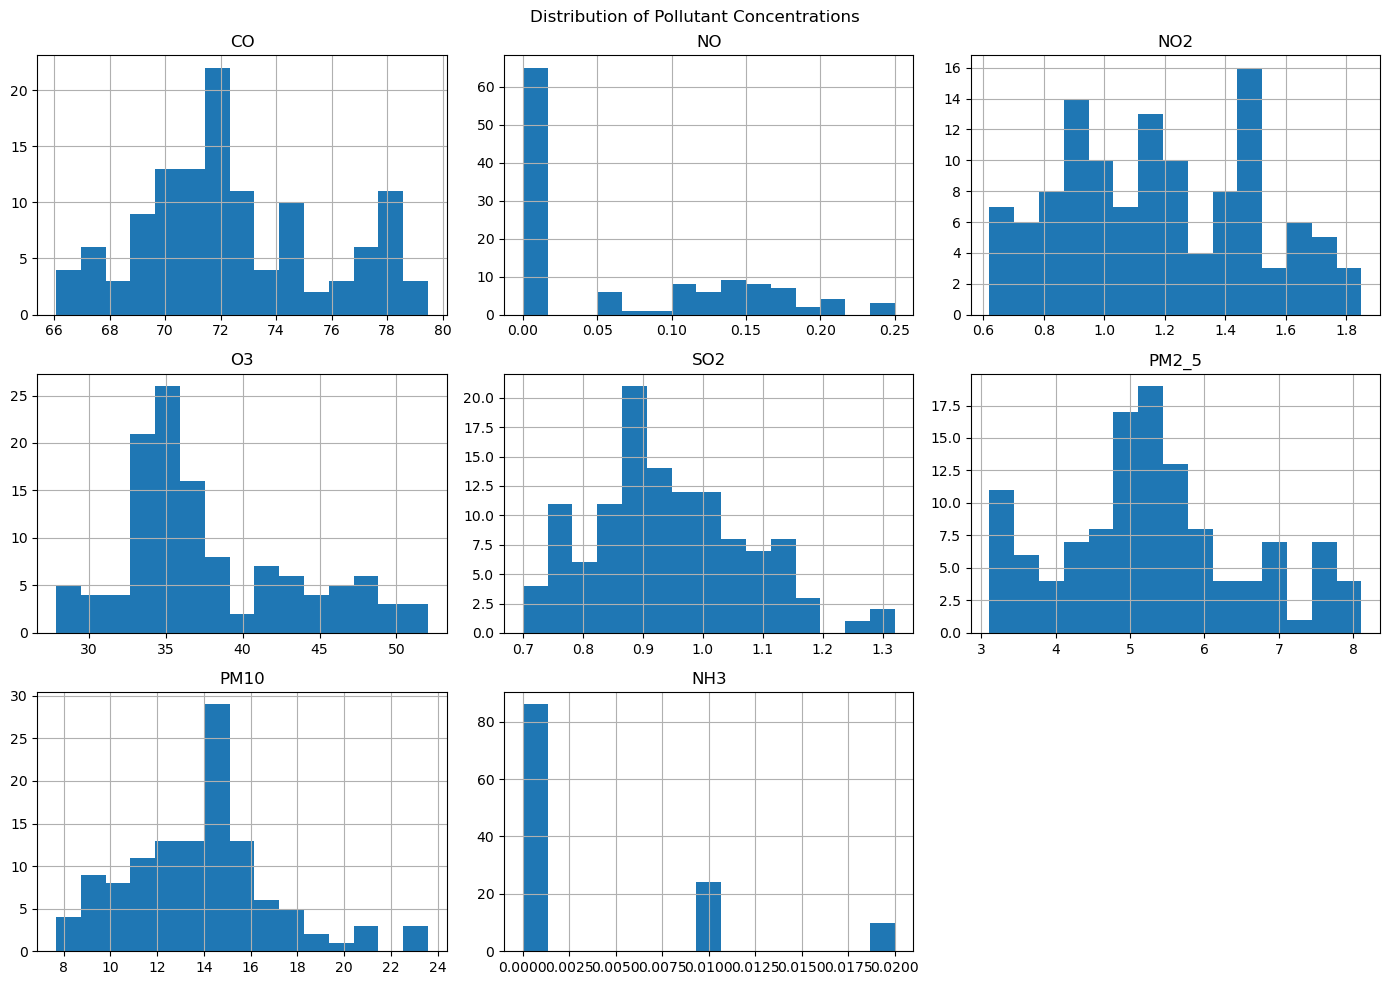

In [11]:
df[pollutant_columns].hist(
    figsize=(14, 10),
    bins=15
)

plt.suptitle("Distribution of Pollutant Concentrations")

plt.tight_layout()
plt.show()

## 8. Skewness Analysis

Skewness measures the asymmetry of a numerical distribution.

Positive skewness indicates a longer right tail, while negative skewness indicates a longer left tail.

The skewness values are examined to determine whether pollutant distributions are substantially asymmetric.

In [12]:
skewness = df[pollutant_columns].skew().sort_values(ascending=False)

print("Pollutant Skewness:")
print(skewness)

Pollutant Skewness:
NH3      1.521866
O3       0.737693
NO       0.682531
PM10     0.566788
SO2      0.502081
PM2_5    0.323208
CO       0.273415
NO2      0.173140
dtype: float64


## 9. Correlation Analysis

Pearson correlation is used as an exploratory measure of linear association between numerical variables.

The analysis helps identify pollutant variables that show stronger or weaker linear relationships with AQI.

Correlation does not imply causation and should therefore be interpreted as an association within this dataset.

In [13]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(3)

,AQI,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,hour,day,month,weekday,AQI_lag_1,AQI_change,AQI_rolling_avg
AQI,1.000,-0.371,-0.168,-0.162,-0.276,-0.186,0.452,0.592,-0.133,0.110,0.290,-0.296,0.305,0.717,0.254,0.619
CO,-0.371,1.000,0.498,0.379,0.602,0.453,-0.880,-0.850,0.611,-0.220,-0.546,0.559,-0.065,-0.367,0.021,-0.359
NO,-0.168,0.498,1.000,-0.183,0.552,0.337,-0.365,-0.508,0.443,-0.466,-0.043,0.041,-0.059,-0.128,-0.045,-0.082
NO2,-0.162,0.379,-0.183,1.000,-0.414,0.667,-0.184,-0.159,0.394,0.075,-0.215,0.229,-0.213,-0.183,0.030,-0.171
O3,-0.276,0.602,0.552,-0.414,1.000,-0.114,-0.697,-0.685,0.243,-0.122,-0.188,0.185,0.152,-0.289,0.042,-0.306
SO2,-0.186,0.453,0.337,0.667,-0.114,1.000,-0.281,-0.315,0.530,0.007,-0.175,0.180,-0.304,-0.202,0.039,-0.199
PM2_5,0.452,-0.880,-0.365,-0.184,-0.697,-0.281,1.000,0.929,-0.483,0.070,0.537,-0.553,0.026,0.436,-0.040,0.471
PM10,0.592,-0.850,-0.508,-0.159,-0.685,-0.315,0.929,1.000,-0.485,0.149,0.493,-0.509,0.199,0.559,-0.045,0.562
NH3,-0.133,0.611,0.443,0.394,0.243,0.530,-0.483,-0.485,1.000,-0.175,-0.166,0.177,-0.128,-0.135,0.031,-0.150
hour,0.110,-0.220,-0.466,0.075,-0.122,0.007,0.070,0.149,-0.175,1.000,0.071,-0.078,0.038,0.009,0.202,-0.165


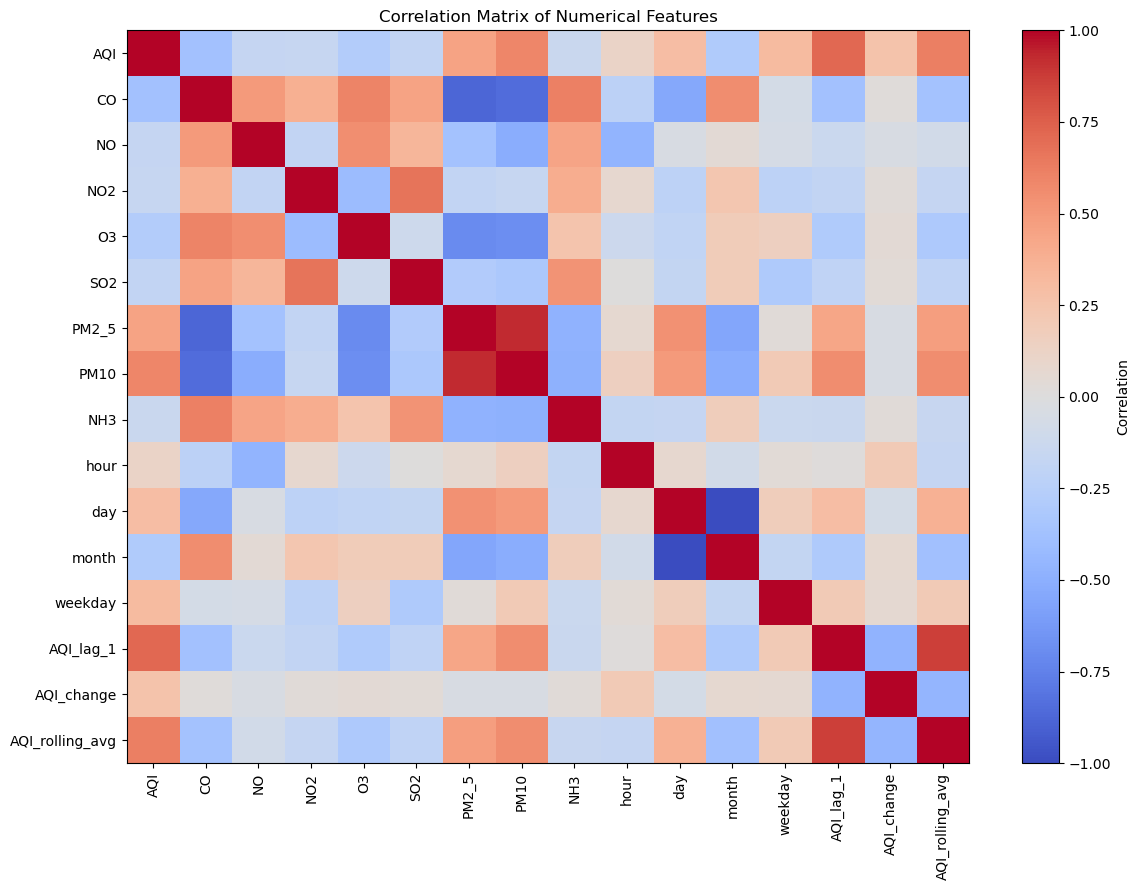

In [ ]:
plt.figure(figsize=(10, 9))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

## 10. AQI Correlation Ranking

The correlation of each numerical feature with AQI is ranked to identify the strongest linear associations.

This ranking is used for interpretation and does not replace model-based feature importance.

In [15]:
aqi_correlation = (
    correlation_matrix["AQI"]
    .drop("AQI")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Features Ranked by Absolute Correlation with AQI:")
print(aqi_correlation.round(3))

Features Ranked by Absolute Correlation with AQI:
AQI_lag_1          0.717
AQI_rolling_avg    0.619
PM10               0.592
PM2_5              0.452
CO                -0.371
weekday            0.305
month             -0.296
day                0.290
O3                -0.276
AQI_change         0.254
SO2               -0.186
NO                -0.168
NO2               -0.162
NH3               -0.133
hour               0.110
Name: AQI, dtype: float64


## 11. Pollutant and AQI Relationships

Scatter plots are used to visually examine the relationship between AQI and the major pollutant variables.

These plots complement the correlation matrix by showing the actual distribution of observations rather than only a single correlation coefficient.

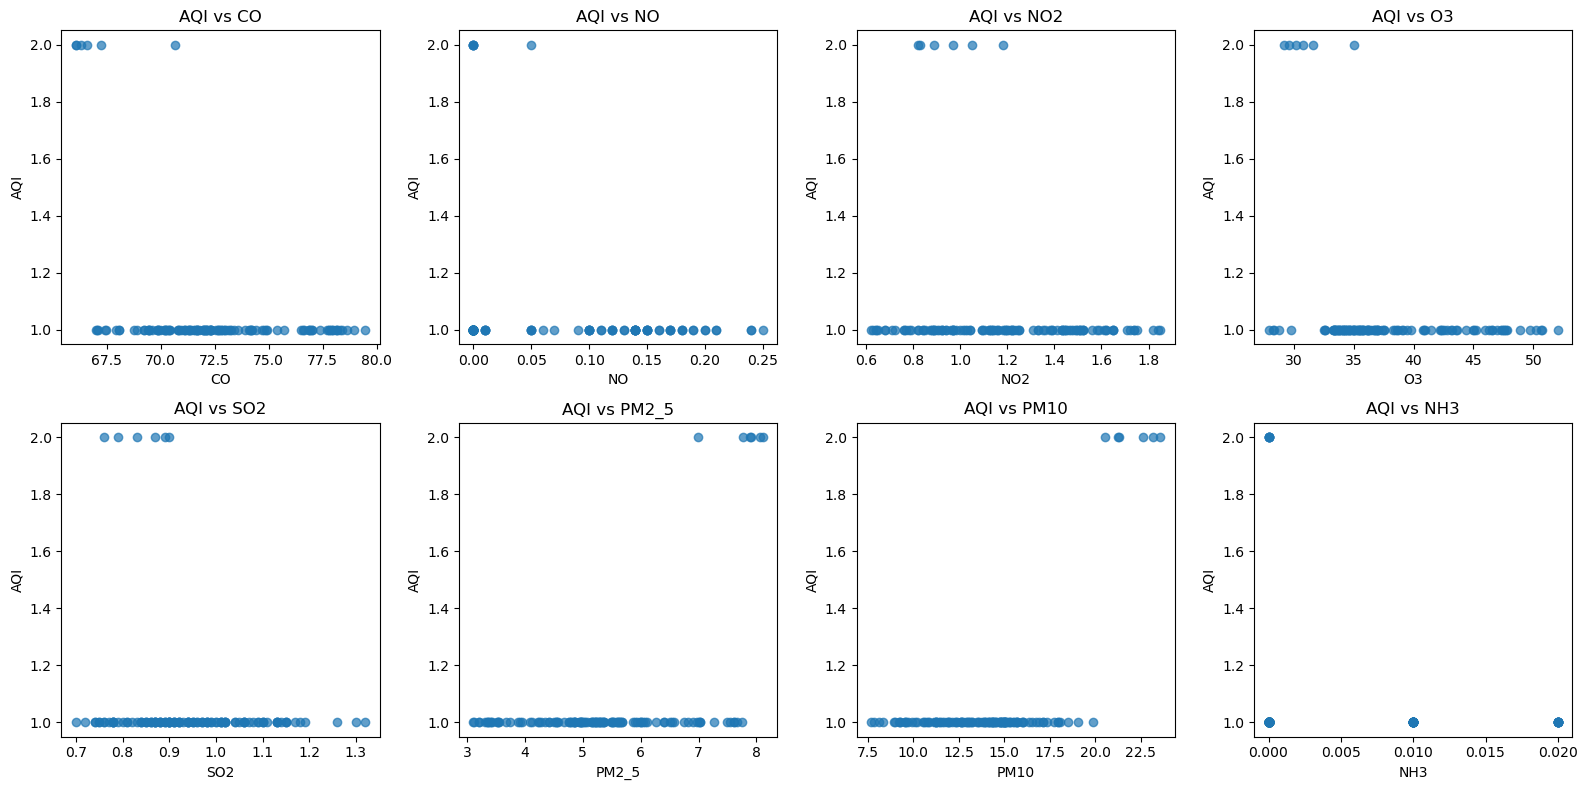

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, column in zip(axes.flatten(), pollutant_columns):
    ax.scatter(df[column], df["AQI"], alpha=0.7)
    ax.set_title(f"AQI vs {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("AQI")

plt.tight_layout()
plt.show()

## 12. Relationship Between PM2.5 and PM10

PM2.5 and PM10 are both particulate-matter measurements.

Their relationship is examined separately because a very strong correlation between predictors may indicate redundancy and potential multicollinearity in a linear model.

In [17]:
pm_correlation = df["PM2_5"].corr(df["PM10"])

print("Correlation between PM2.5 and PM10:", round(pm_correlation, 3))

Correlation between PM2.5 and PM10: 0.929


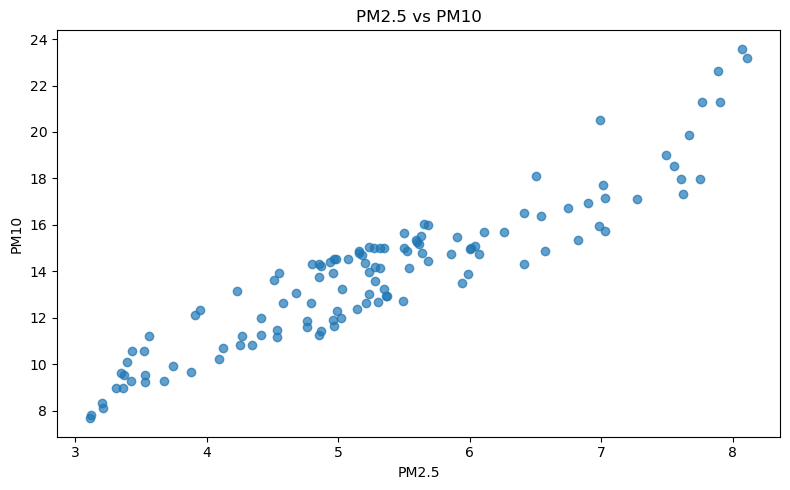

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["PM2_5"],
    df["PM10"],
    alpha=0.7
)

plt.title("PM2.5 vs PM10")
plt.xlabel("PM2.5")
plt.ylabel("PM10")

plt.tight_layout()
plt.show()

## 13. Outlier Analysis Using IQR

The Interquartile Range method is used to identify observations that fall outside the typical distributional range.

Potential outliers are reported rather than automatically removed.

In environmental datasets, extreme pollutant concentrations can represent genuine pollution events. Therefore, statistical detection alone is not sufficient justification for deleting observations.

In [19]:
analysis_columns = [
    "AQI",
    "CO",
    "NO",
    "NO2",
    "O3",
    "SO2",
    "PM2_5",
    "PM10",
    "NH3"
]

Q1 = df[analysis_columns].quantile(0.25)
Q3 = df[analysis_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = (
    (df[analysis_columns] < lower_bound) |
    (df[analysis_columns] > upper_bound)
).sum()

outlier_summary = pd.DataFrame({
    "Outlier_Count": outlier_count,
    "Total_Observations": len(df),
    "Outlier_Percentage": (outlier_count / len(df)) * 100
})

outlier_summary.round(2)

,Outlier_Count,Total_Observations,Outlier_Percentage
AQI,6,120,5.00
CO,0,120,0.00
NO,0,120,0.00
NO2,0,120,0.00
O3,0,120,0.00
SO2,2,120,1.67
PM2_5,0,120,0.00
PM10,5,120,4.17
NH3,0,120,0.00


## 14. Visual Outlier Inspection

Boxplots provide a visual representation of the median, interquartile range, and potential extreme observations.

Different pollutants operate on different numerical scales, so the boxplots are interpreted individually rather than comparing absolute box sizes across variables.

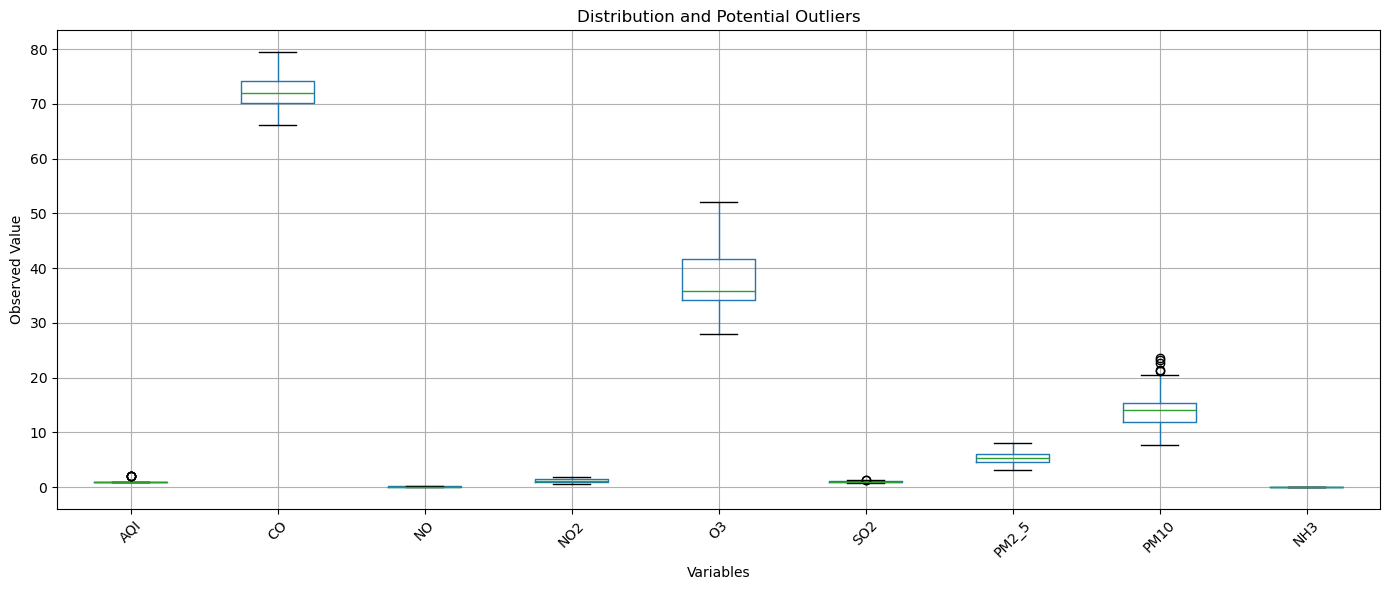

In [20]:
plt.figure(figsize=(14, 6))

df[analysis_columns].boxplot()

plt.title("Distribution and Potential Outliers")
plt.xlabel("Variables")
plt.ylabel("Observed Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. Observations by Weekday

The number of observations available for each weekday is examined to determine whether the dataset has an uneven temporal representation.

This is a data-coverage analysis rather than evidence that weekdays directly cause changes in AQI.

In [21]:
weekday_counts = df["weekday"].value_counts()

print(weekday_counts)

weekday
0    24
1    24
2    24
3    24
6    21
4     3
Name: count, dtype: int64


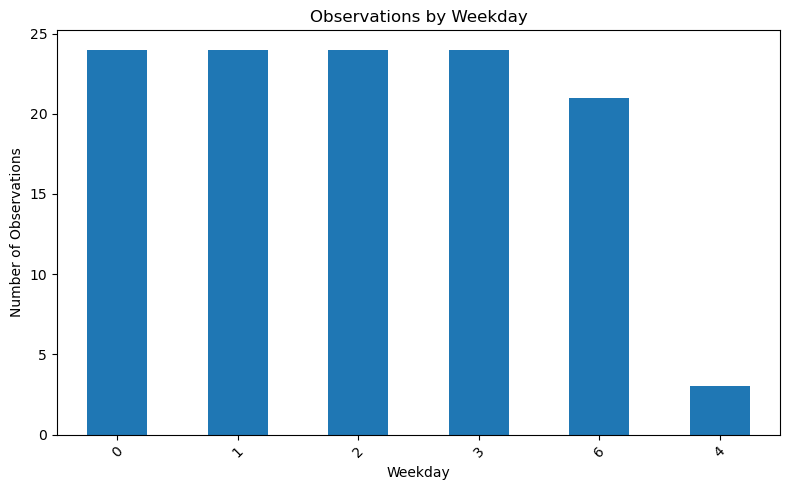

In [22]:
plt.figure(figsize=(8, 5))

weekday_counts.plot(kind="bar")

plt.title("Observations by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Observations")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16. AQI Rolling Behaviour

The three-observation rolling average is compared with the observed AQI to visualize short-term smoothing.

The rolling feature is based on previous observations and is intended to capture recent temporal behaviour.

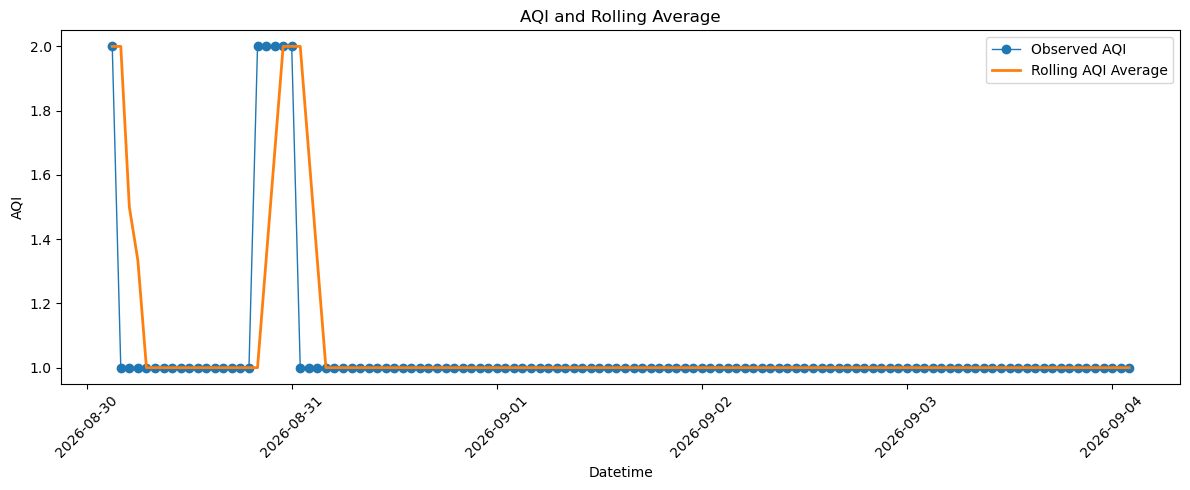

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["AQI"],
    label="Observed AQI",
    marker="o",
    linewidth=1
)

plt.plot(
    df["datetime"],
    df["AQI_rolling_avg"],
    label="Rolling AQI Average",
    linewidth=2
)

plt.title("AQI and Rolling Average")
plt.xlabel("Datetime")
plt.ylabel("AQI")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## 17. Engineered Feature Relationships

The temporal and lag-based features are examined alongside AQI to understand whether recent AQI behaviour contains useful information for prediction.

These relationships are exploratory and will be validated through out-of-sample model evaluation.

In [24]:
engineered_features = [
    "AQI_lag_1",
    "AQI_change",
    "AQI_rolling_avg",
    "hour",
    "day",
    "month"
]

engineered_correlation = (
    df[["AQI"] + engineered_features]
    .corr()["AQI"]
    .drop("AQI")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print(engineered_correlation.round(3))

AQI_lag_1          0.717
AQI_rolling_avg    0.619
month             -0.296
day                0.290
AQI_change         0.254
hour               0.110
Name: AQI, dtype: float64


## 18. Analytical Summary

The following section summarizes the main statistical observations obtained from the exploratory analysis.

The results are generated directly from the dataset to reduce manual interpretation errors.

In [25]:
strongest_feature = aqi_correlation.index[0]
strongest_correlation = aqi_correlation.iloc[0]

highest_skew_feature = skewness.index[0]
highest_skew_value = skewness.iloc[0]

pm_correlation = df["PM2_5"].corr(df["PM10"])

print("EDA SUMMARY")
print("-" * 40)

print(
    f"Strongest absolute linear association with AQI: "
    f"{strongest_feature} ({strongest_correlation:.3f})"
)

print(
    f"Most positively skewed pollutant: "
    f"{highest_skew_feature} ({highest_skew_value:.3f})"
)

print(
    f"PM2.5 and PM10 correlation: "
    f"{pm_correlation:.3f}"
)

print(
    f"Number of observations: {len(df)}"
)

print(
    f"Number of numerical variables: {len(numeric_columns)}"
)

EDA SUMMARY
----------------------------------------
Strongest absolute linear association with AQI: AQI_lag_1 (0.717)
Most positively skewed pollutant: NH3 (1.522)
PM2.5 and PM10 correlation: 0.929
Number of observations: 120
Number of numerical variables: 16


## 19. Key Findings

The exploratory analysis provides several important observations for the subsequent modelling stage:

1. AQI exhibits temporal variation across the observation period, confirming the importance of maintaining chronological ordering.

2. Pollutant variables show different distributional characteristics and levels of variability.

3. Pollutant variables have different strengths and directions of linear association with AQI.

4. Particulate-matter variables, particularly PM2.5 and PM10, should be examined carefully because strong inter-feature correlation may introduce redundancy.

5. IQR analysis identifies potential extreme observations. These observations are retained unless there is evidence that they represent invalid measurements.

6. Lag-based and rolling features provide information about recent AQI behaviour and are therefore relevant candidates for time-dependent modelling.

7. The exploratory findings provide guidance for feature selection and model development, while final feature usefulness must be determined through out-of-sample evaluation.

## 20. Dataset Limitation

The current dataset represents a relatively short observation period for a time-series forecasting problem.

Therefore, the observed temporal patterns should not be interpreted as long-term seasonal behaviour.

The dataset is suitable for developing and validating the project pipeline, but a production-grade forecasting system would benefit from a substantially longer historical record covering multiple weeks, months, or preferably multiple seasonal cycles.

This limitation is important when interpreting model performance and generalization to future observations.

## 21. Final EDA Verification

The final dataset dimensions and basic quality indicators are reported before moving to model development.

In [26]:
print("Final EDA Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDate Range:")
print(df["datetime"].min(), "to", df["datetime"].max())

Final EDA Dataset Shape: (120, 17)

Missing Values:
1

Duplicate Rows:
0

Date Range:
2026-08-30 03:00:00 to 2026-09-04 02:00:00


In [28]:
df = pd.read_csv("../data/processed/AQI_feature_engineered.csv")
df.shape

(120, 17)